# Поиск ассоциативных правил

**Выполнил**: *Никончук В.И. ЕТ-443*

**Постановка задачи**:

1. Доработайте программу из задания Поиск частых наборов, чтобы она также выполняла поиск ассоциативных правил. Список результирующих правил должен выдаваться в удобочитаемом виде (антецедент→консеквент) с указанием поддержки и достоверности каждого правила. Дополнительные параметры программы: порог достоверности, способ упорядочивания результирующего списка наборов (по убыванию значения поддержки или лексикографическое).

2. Проведите эксперименты на наборах из задания 1. В экспериментах Зафиксируйте значение пороговое значение поддержки (например, 10%), варьируйте пороговое значение достоверности (например, от 70% до 95% с шагом 5%).

3. Выполните визуализацию полученных результатов в виде следующих диаграмм:

 - сравнение быстродействия поиска правил на фиксированном наборе данных при изменяемом пороге достоверности;
 - общее количество найденных правил на фиксированном наборе данных при изменяемом пороге достоверности.

4. Подготовьте список правил, в которых антецедент и консеквент суммарно включают в себя не более семи объектов (разумное количество). Проанализируйте и изложите содержательный смысл полученного результата.

5. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  

 - формулировка задания; 
 - гиперссылка на каталог репозитория с исходными текстами, наборами данных и др. сопутствующими материалами; 
 - рисунки с результатами визуализации; 
 - пояснения, раскрывающие смысл полученных результатов.

## **Задание 1**

1. Доработайте программу из задания Поиск частых наборов, чтобы она также выполняла поиск ассоциативных правил. Список результирующих правил должен выдаваться в удобочитаемом виде (антецедент→консеквент) с указанием поддержки и достоверности каждого правила. Дополнительные параметры программы: порог достоверности, способ упорядочивания результирующего списка наборов (по убыванию значения поддержки или лексикографическое).

### Подключение библиотек

In [179]:
import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend import frequent_patterns as fp
import matplotlib.pyplot as plt
from typing import Callable
import time

### Чтение файлов

Данная часть кода полностью повторяется из прошлого решения

In [180]:
input_file = "../1-Apriori/baskets-utf-8.csv"
# input_file = "groceries.csv"

with open(input_file, 'r', encoding='utf-8') as f:
    data = []
    for line in f:
        set = [item.strip() for item in line.strip().split(',') if item.strip()]
        data.append(set)
data[:3]

[['креветки',
  'миндаль',
  'авокадо',
  'овощная смесь',
  'зеленый виноград',
  'цельнозерновая мука',
  'батат',
  'творог',
  'энергетический напиток',
  'томатный сок',
  'низкокалорийный йогурт',
  'зеленый чай',
  'мед',
  'салат',
  'минеральная вода',
  'лосось',
  'ягодный сок',
  'замороженный смузи',
  'шпинат',
  'оливковое масло'],
 ['гамбургер', 'фрикадельки', 'яйца'],
 ['чатни']]

In [181]:
te = TransactionEncoder()
binary_transactions = te.fit_transform(data)
binary_transactions_df = pd.DataFrame(binary_transactions, columns=te.columns_) # type: ignore

binary_transactions_df

,авокадо,аксессуары,баклажаны,батат,батончик без глютена,бекон,белое вино,белый сыр,блинчики,ветчина,...,чили,шампанское,шампунь,шоколад,шпинат,энергетический батончик,энергетический напиток,эскалоп,ягодный сок,яйца
0,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7499,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### Функция получения ассоциативных правил


Ассоциативное правило - это логическая зависимость вида "Если произошло X, то с высокой вероятностью произойдет событие Y". Данные правила часто используются в системах рекомендаций.

У ассоциативных правил есть несколько показателей.

1. Поддержка (`support`). Показывает насколько часто комбинация встречается в наборе данных.
2. Доверие (`confidence`). Показывает с какой частотой происходит событие Y при возникновении события X.

In [182]:
def search_frequent_sets(
        binary_transactions: pd.DataFrame, 
        min_support: float, 
        sort_by: str
    ) -> pd.DataFrame:

    if (min_support > 1.0 or min_support < 0.0 or 
        sort_by not in ['support_desc', 'lexicographic']) :
        raise Exception("Параметры определены неверно")

    friquent_sets = fp.apriori(binary_transactions, min_support=min_support, use_colnames=True)

    if (sort_by == 'support_desc'):
        friquent_sets.sort_values(by='support', ascending=False, inplace=True)
    else:
        friquent_sets.sort_values(by='itemsets', ascending=True, inplace=True)

    return friquent_sets

In [183]:
def generate_association_rules(
        friquent_sets: pd.DataFrame, 
        min_confidence: float, 
        sort_by: str
    ) -> pd.DataFrame:

    if (min_confidence > 1.0 or min_confidence < 0.0 or 
        sort_by not in ['support_desc', 'lexicographic']) :
        raise Exception("Параметры определены неверно")

    association_rules = fp.association_rules(
        friquent_sets, metric='confidence', min_threshold=min_confidence, 
        return_metrics=['support', 'confidence'])

    if (sort_by == 'support_desc'):
        association_rules.sort_values(by='support', ascending=False, inplace=True)
    else:
        association_rules.sort_values(by=['antecedents', 'consequents'], ascending=[True, True], inplace=True)

    return association_rules
    

In [184]:
friquent_sets = search_frequent_sets(
    binary_transactions_df,
    min_support=0.05,
    sort_by='support_desc'
)

association_rules = generate_association_rules(
    friquent_sets,
    min_confidence=0.2,
    sort_by='support_desc'
)

association_rules

,antecedents,consequents,support,confidence
0,frozenset({минеральная вода}),frozenset({макароны}),0.061192,0.256711
1,frozenset({макароны}),frozenset({минеральная вода}),0.061192,0.325532
2,frozenset({шоколад}),frozenset({минеральная вода}),0.052660,0.321400
3,frozenset({минеральная вода}),frozenset({шоколад}),0.052660,0.220917
4,frozenset({яйца}),frozenset({минеральная вода}),0.050927,0.283383
5,frozenset({минеральная вода}),frozenset({яйца}),0.050927,0.213647


# **Задание 2**

2. Проведите эксперименты на наборах из задания 1. В экспериментах Зафиксируйте значение пороговое значение поддержки (например, 10%), варьируйте пороговое значение достоверности (например, от 70% до 95% с шагом 5%).

In [185]:
min_support = 0.01
plot_title = f"Значение минимальной поддержки: {min_support * 100} %"
friquent_sets = search_frequent_sets(
    binary_transactions_df,
    min_support,
    'support_desc'
)

friquent_sets

,support,itemsets
31,0.238368,frozenset({минеральная вода})
26,0.187975,frozenset({макароны})
73,0.179709,frozenset({яйца})
20,0.170911,frozenset({картофель-фри})
69,0.163845,frozenset({шоколад})
...,...,...
210,0.010265,"frozenset({минеральная вода, хлопья})"
124,0.010265,"frozenset({замороженные овощи, торт})"
120,0.010132,"frozenset({низкокалорийный йогурт, замороженны..."
248,0.010132,"frozenset({яйца, минеральная вода, говяжий фарш})"


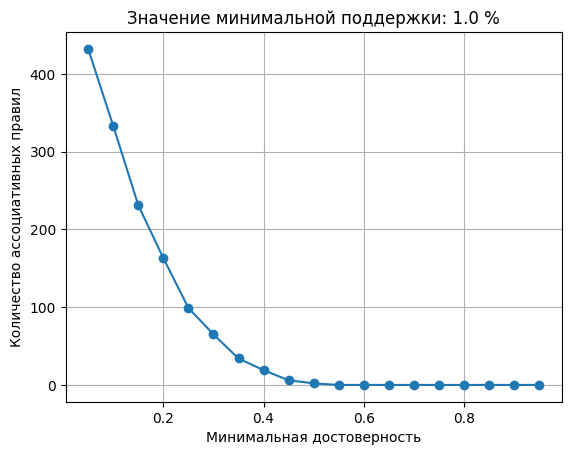

In [186]:
min_confidences = np.arange(0.05, 0.96, 0.05)
total_rules_count = []


for confidence in list(min_confidences):
    rules = generate_association_rules(friquent_sets, float(confidence), 'lexicographic')
    total_rules_count.append(len(rules))

plt.plot(min_confidences, total_rules_count, marker="o")
plt.title(plot_title)
plt.xlabel('Минимальная достоверность')
plt.ylabel('Количество ассоциативных правил')
plt.grid(True)
plt.show()

# **Задание 3**

3. Выполните визуализацию полученных результатов в виде следующих диаграмм:

 - сравнение быстродействия поиска правил на фиксированном наборе данных при изменяемом пороге достоверности;
 - общее количество найденных правил на фиксированном наборе данных при изменяемом пороге достоверности.

In [187]:
def measure_execution_time(callback: Callable[[], None]) -> float:
    start_time = time.time()
    callback()
    stop_time = time.time()
    return stop_time - start_time

In [188]:
min_support = 0.005
plot_title = f"Значение минимальной поддержки: {min_support * 100} %"
friquent_sets = search_frequent_sets(
    binary_transactions_df,
    min_support,
    'support_desc'
)

friquent_sets

,support,itemsets
41,0.238368,frozenset({минеральная вода})
36,0.187975,frozenset({макароны})
96,0.179709,frozenset({яйца})
26,0.170911,frozenset({картофель-фри})
90,0.163845,frozenset({шоколад})
...,...,...
485,0.005066,"frozenset({растительное масло, оливковое масло})"
451,0.005066,"frozenset({молоко, перец})"
417,0.005066,"frozenset({минеральная вода, обезжиренное моло..."
707,0.005066,"frozenset({шоколад, помидоры, макароны})"


## График времени исполнения

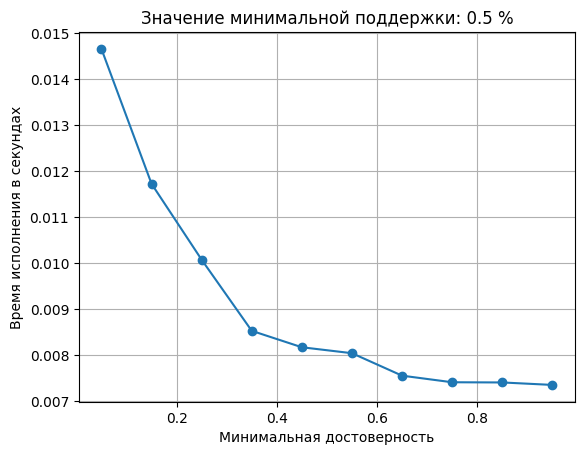

In [189]:
execution_times = []
min_confidences = np.arange(0.05, 0.96, 0.1)

for confidence in list(min_confidences):
    repeat_times = 100
    execution_time = .0
    for i in range(repeat_times):
        execution_time += measure_execution_time(lambda: generate_association_rules(
            friquent_sets,
            min_confidence=confidence,
            sort_by="support_desc"
        )) # type: ignore
    execution_time /= repeat_times
    execution_times.append(execution_time)

plt.plot(min_confidences, execution_times, marker="o")
plt.title(plot_title)
plt.xlabel('Минимальная достоверность')
plt.ylabel('Время исполнения в секундах')
plt.grid(True)
plt.show()

Как показано на графике, среднее время исполнения уменьшается при увеличении минимальной достоверности. Используется постоянное значение минимальной поддержки. Это  связано с тем, что при большой минимальной достоверности меньше правил проходит отбор. Для них алгоритм вычисления не проводит.

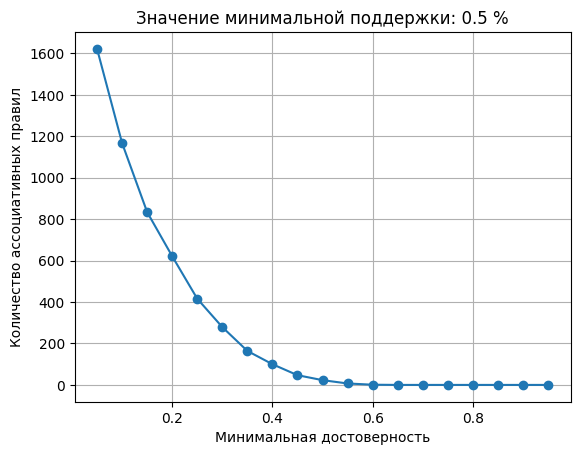

In [190]:
min_confidences = np.arange(0.05, 0.96, 0.05)
total_rules_count = []


for confidence in list(min_confidences):
    rules = generate_association_rules(friquent_sets, float(confidence), 'lexicographic')
    total_rules_count.append(len(rules))

plt.plot(min_confidences, total_rules_count, marker="o")
plt.title(plot_title)
plt.xlabel('Минимальная достоверность')
plt.ylabel('Количество ассоциативных правил')
plt.grid(True)
plt.show()

# **Задание 4**

4. Подготовьте список правил, в которых антецедент и консеквент суммарно включают в себя не более семи объектов (разумное количество). Проанализируйте и изложите содержательный смысл полученного результата.

> Сначала определим при каком минимальной поддержке достигается наибольшее количество правил с минимальной достоверностью 0.4

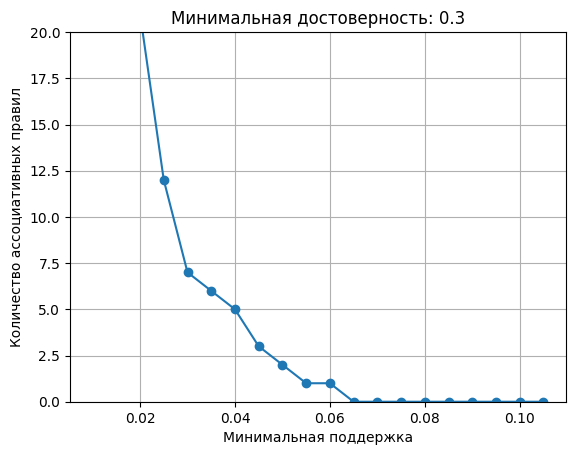

In [191]:
min_confidence = 0.3
min_supports = np.arange(0.01, 0.11, 0.005)
total_rules_counts = []

for support in list(min_supports):
    fr_sets = search_frequent_sets(binary_transactions_df, support, "lexicographic")
    rules = generate_association_rules(fr_sets, min_confidence, "lexicographic")

    rules = rules[rules['antecedents'].apply(len) + rules['consequents'].apply(len) <= 7]
    # Только правила, в которых антецедент и консеквент 
    # cуммарно включают в себя не более семи объектов 

    total_rules_counts.append(len(rules))

plt.plot(min_supports, total_rules_counts, marker="o")
plt.title(f"Минимальная достоверность: {min_confidence}")
plt.xlabel("Минимальная поддержка")
plt.ylabel("Количество ассоциативных правил")
plt.ylim((0, 20))
plt.grid(True)
plt.show()

> Как видно из рисунка выше, при минимальной поддержке 0.04 и достоверности 0.3 удалось найти 5 значимых ассоциативных правила. Давайте посмотрим на эти правила.

In [192]:
min_confidence = 0.3
min_support = 0.04

fr_sets = search_frequent_sets(binary_transactions_df, min_support, "support_desc")
rules = generate_association_rules(fr_sets, min_confidence, "support_desc")

rules

,antecedents,consequents,support,confidence
0,frozenset({макароны}),frozenset({минеральная вода}),0.061192,0.325532
1,frozenset({шоколад}),frozenset({минеральная вода}),0.052660,0.321400
2,frozenset({молоко}),frozenset({минеральная вода}),0.047994,0.370370
3,frozenset({говяжий фарш}),frozenset({минеральная вода}),0.040928,0.416554
4,frozenset({говяжий фарш}),frozenset({макароны}),0.040261,0.409769
